In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from glob import glob 

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx

from scipy.stats import chi2_contingency


/usr/local/lib/python3.8/dist-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.2-CAPI-1.17.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/tmp/tmp.SpyaxXj29O/ipykernel_1102091/3802811046.py:7: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration

### Collect the hourly accumulation for every site and hour from 2024 through 2026

In [2]:
# Takes about 30-60 sec to run
# Setup your file list and a place to store results
# Use 2024 and 2025 b/c didn't have labeled data from those dates
dir2024 = glob("/home/csutter/NYSM/netcdf/proc/2024/*/*")
print(len(dir2024)) # leap year, 366 days
dir2025 = glob("/home/csutter/NYSM/netcdf/proc/2025/*/*")
print(len(dir2025))
dir2026 = glob("/home/csutter/NYSM/netcdf/proc/2026/*/*")
print(len(dir2026))
files = dir2024+dir2025+dir2026
print(len(files))

results = []

for filename in files:
    ds = xr.open_dataset(filename)
    
    # 1. Get the "Standard" Hourly indices (00:00, 01:00, ..., 23:00)
    hour_mask = ds.time_5M.dt.minute == 0
    hourly_data = ds.isel(time_5M=hour_mask)
    
    # 2. Grab the 00:05 snapshot specifically
    # This is our "Safe Start" to avoid midnight resets
    start_0005 = ds.sel(time_5M=ds.time_5M.dt.hour == 0).isel(time_5M=1) # The 2nd entry (00:05)
    
    station_names = ds.station.values
    times = hourly_data.time_5M.values # [00:00, 01:00, 02:00...]

    # 3. Loop through the hours
    # We skip t_idx 0 (00:00) because we can't calculate a delta for it 
    # (it IS the starting point)
    for t_idx in range(1, len(times)):
        timestamp = times[t_idx]
        ts_str = pd.to_datetime(timestamp).strftime('%Y-%m-%d %H:%M')
        
        # Determine our "Previous" value
        if t_idx == 1:
            # For the 01:00 AM delta, subtract the 00:05 value
            prev_snow = start_0005['snow_depth'].values
            prev_precip = start_0005['precip'].values
        else:
            # For all other hours, use the previous top-of-the-hour
            prev_snow = hourly_data['snow_depth'].isel(time_5M=t_idx-1).values
            prev_precip = hourly_data['precip'].isel(time_5M=t_idx-1).values
            
        current_snow = hourly_data['snow_depth'].isel(time_5M=t_idx).values
        current_precip = hourly_data['precip'].isel(time_5M=t_idx).values
        current_tair = hourly_data['tair'].isel(time_5M=t_idx).values
        
        # Calculate Deltas
        snow_deltas = current_snow - prev_snow
        precip_deltas = current_precip - prev_precip
        
        for s_idx, station_id in enumerate(station_names):
            results.append({
                'timestamp': ts_str,
                'station': station_id,
                'snow_delta': float(snow_deltas[s_idx]),
                'precip_delta': float(precip_deltas[s_idx]),
                'tair': float(current_tair[s_idx])
            })
            
    ds.close()

366
365
93
824


In [3]:
# Convert to dataframe

df = pd.DataFrame(results)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['snow_delta'] = pd.to_numeric(df['snow_delta'])
df['precip_delta'] = pd.to_numeric(df['precip_delta'])
df['date_only'] = pd.to_datetime(df['timestamp']).dt.date

print(len(df))

print(92701*24) # roughly matching the hourly dataset as expected

2403776
2224824


In [ ]:
df.head(4)


In [ ]:
# df[((df["station"]=="DELE")&(df["date_only"]==pd.to_datetime("2024-12-13").date()))]

In [4]:
# Only want to look for winter months
# Dec (12), Jan (1), Feb (2), Mar (3)
winter_months = [12, 1, 2, 3]

#  Filter the DataFrame
# .dt.month extracts the month number from the datetime object
winter_df = df[df['timestamp'].dt.month.isin(winter_months)]
winter_df.head(5)

,timestamp,station,snow_delta,precip_delta,tair,date_only
265811,2024-03-21 01:00:00,ADDI,-0.001206,0.0,-5.240284,2024-03-21
265812,2024-03-21 01:00:00,ANDE,0.003452,0.0,-4.460862,2024-03-21
265813,2024-03-21 01:00:00,BATA,0.002514,0.0,-4.270832,2024-03-21
265814,2024-03-21 01:00:00,BEAC,-0.000921,0.0,0.951035,2024-03-21
265815,2024-03-21 01:00:00,BELD,-0.000320,0.0,-4.854388,2024-03-21


### Find top datetimes for each station, accounting for the fact that we want dates to be spread out (i.e. not all 20 highest precip datetimes being from the same 3 dates)

Way 1 - Using this method

In [5]:
# 1 - grab all model preds that have been ran

# alldirs_data_preds = glob("/home/csutter/DRIVE-clean/operational_runs_QPEdata/data_6_ensembling") #HERE!! Where model pred data lives

alldirs_data_preds = glob("/home/csutter/DRIVE-clean/operational_runs/*/data_6_ensembling") #HERE!! Where model pred data lives

# grab ALL model pred file paths
allfiles_data = []
for i in alldirs_data_preds:
    fs = glob(f"{i}/*/*/*/*/*")
    allfiles_data.extend(fs)

# Pre-parse the times into a dictionary
# The dict maps '20240217_1430' -> '/full/path/to/file.csv'
# The dict is used to search for the file path given a date that is needed for an event (Loop 3)
file_lookup_dict = {}
for f in allfiles_data:
    beg = f.rfind("/")
    time_key = f[beg-13:beg]
    # log all string times of interest with the corresponding model pred file in dictionary
    file_lookup_dict[time_key] = f


# def get_weather_regimes_with_models(dataframe, column, file_lookup, mode='high_snow', n_per_station=20):
#     """
#     mode: 'high_snow', 'high_precip', or 'dry'
#     """
#     df_temp = dataframe.dropna(subset=[column]).copy() # drop nan values of the cols we're looking at
    
#     # Pre-check: format timestamp and filter for available model files
#     df_temp['timestamp_formatted'] = df_temp['timestamp'].dt.strftime('%Y%m%d_%H%M')
#     df_temp = df_temp[df_temp['timestamp_formatted'].isin(file_lookup.keys())]

#     if mode == 'high_snow':
#         # Logic: Highest positive snow accumulation
#         # Usually implies tair <= 0, but we let the data speak for itself
#         sorted_df = df_temp.sort_values('snow_delta', ascending=False)
#         unique_events = sorted_df.drop_duplicates(['station', 'date_only'])

#     elif mode == 'high_precip':
#         # Logic: Highest liquid precipitation (Rain Guard: tair > 2.0)
#         df_temp = df_temp[df_temp['tair'] > 4.4] # over 40F
#         sorted_df = df_temp.sort_values('precip_delta', ascending=False)
#         unique_events = sorted_df.drop_duplicates(['station', 'date_only'])

#     elif mode == 'dry':

#         # Logic: Find days where the sum of absolute hourly changes is lowest
#         # This identifies the 24-hour periods with the least amount of movement.
#         df_temp['daily_total_precip'] = df_temp.groupby(['station', 'date_only'])['precip_delta'].transform(lambda x: x.abs().sum()) # looks at the sum of all your hourly deltas across the entire day
        
#         # Identify the unique days for each station, sorted by lowest total precip first
#         unique_days = df_temp.sort_values('daily_total_precip', ascending=True).drop_duplicates(['station', 'date_only'])
        
#         # Take the top N driest days for each station
#         driest_days_summary = unique_days.groupby('station').head(n_per_station).copy()
        
#         # Pick one random hour from each of those identified dry days
#         dry_indices = []
#         for _, row in driest_days_summary.iterrows():
#             day_hours = df_temp[(df_temp['station'] == row['station']) & 
#                                 (df_temp['date_only'] == row['date_only'])]
#             dry_indices.append(day_hours.sample(1, random_state=42))
            
#         unique_events = pd.concat(dry_indices)


#     # Final Sampling: Top N unique-day events per station
#     final_sample = unique_events.groupby('station').head(n_per_station).copy()
#     final_sample['modelpred_file'] = final_sample['timestamp_formatted'].map(file_lookup)
        
#     return final_sample.reset_index(drop=True)


# def get_weather_regimes_with_models(dataframe, column, file_lookup, mode='high_snow', n_per_station=20, preferred_max_per_day=4):
#     df_temp = dataframe.copy()
    
#     # 1. File availability check
#     df_temp['timestamp_formatted'] = df_temp['timestamp'].dt.strftime('%Y%m%d_%H%M')
#     df_temp = df_temp[df_temp['timestamp_formatted'].isin(file_lookup.keys())]

#     # 2. Mode-specific filtering
#     if mode == 'high_snow':
#         # Apply your ~1-inch floor (0.025m)
#         active_df = df_temp[df_temp['snow_delta'] > 0.025].sort_values('snow_delta', ascending=False)
#     elif mode == 'high_precip':
#         # Rain Guard and positive precip
#         active_df = df_temp[(df_temp['tair'] > 4.4) & (df_temp['precip_delta'] > 0)].sort_values('precip_delta', ascending=False)
#     elif mode == 'dry':
#         # Dry logic remains a special case (we don't need the soft-cap here usually)
#         df_temp['daily_total_precip'] = df_temp.groupby(['station', 'date_only'])['precip_delta'].transform(lambda x: x.abs().sum())
#         unique_days = df_temp.sort_values('daily_total_precip', ascending=True).drop_duplicates(['station', 'date_only'])
#         driest_days = unique_days.groupby('station').head(n_per_station)
        
#         dry_samples = []
#         for _, row in driest_days.iterrows():
#             day_hours = df_temp[(df_temp['station'] == row['station']) & (df_temp['date_only'] == row['date_only'])]
#             dry_samples.append(day_hours.sample(1, random_state=42))
#         return pd.concat(dry_samples).reset_index(drop=True)

#     # 3. The "Soft Cap" Logic for Snow/Precip
#     final_indices = []
    
#     for station, station_data in active_df.groupby('station'):
#         # Pass 1: Take up to 4 best hours per day
#         pass1 = station_data.groupby('date_only').head(preferred_max_per_day)
        
#         # If Pass 1 already gives us enough, take the top N
#         if len(pass1) >= n_per_station:
#             final_indices.append(pass1.head(n_per_station))
#         else:
#             # Pass 2: We need more. Take the hours we skipped in Pass 1
#             remaining_data = station_data.drop(pass1.index)
#             needed = n_per_station - len(pass1)
            
#             # Combine Pass 1 with the next best available hours
#             combined = pd.concat([pass1, remaining_data.head(needed)])
#             final_indices.append(combined)

#     unique_events = pd.concat(final_indices) if final_indices else pd.DataFrame()

#     # 4. Map the model files
#     unique_events['modelpred_file'] = unique_events['timestamp_formatted'].map(file_lookup)
        
#     return unique_events.reset_index(drop=True)

def get_weather_regimes_with_models(dataframe, column, file_lookup, mode='high_snow', snow_thresh_m=0.0508, rain_thresh_mm=10.0):
    
    """
    mode: 'high_snow', 'high_precip', or 'dry'
    """

    df_temp = dataframe.copy()
    df_temp['timestamp_formatted'] = df_temp['timestamp'].dt.strftime('%Y%m%d_%H%M')
    df_temp = df_temp[df_temp['timestamp_formatted'].isin(file_lookup.keys())]

    active_col = 'snow_delta' if 'snow' in mode else 'precip_delta'
    df_temp = df_temp.dropna(subset=[active_col]).copy()

    if mode == 'high_snow':
        unique_events = df_temp[df_temp['snow_delta'] >= snow_thresh_m].sort_values('snow_delta', ascending=False)

    elif mode == 'high_precip':
        # Rain Guard (> 4.4C) and using the mm/hr threshold
        unique_events = df_temp[(df_temp['tair'] > 4.4) & (df_temp['precip_delta'] >= rain_thresh_mm)].sort_values('precip_delta', ascending=False)

    elif mode == 'dry':
        # Grab whole days with essentially no precip (b/c we don't want to find some random one hour on a date that rained the remaining 23 hours)
        df_temp['daily_total_precip'] = df_temp.groupby(['station', 'date_only'])['precip_delta'].transform(lambda x: x.abs().sum())
        # Also grab days with little to no snow melt (runoff / wet roads)
        # Add a check for the maximum hourly snow movement (melt or accumulation) that day
        df_temp['daily_max_snow_move'] = df_temp.groupby(['station', 'date_only'])['snow_delta'].transform(lambda x: x.abs().sum())

        dry_days = df_temp[df_temp['daily_total_precip'] < 0.001] # < 0.001mm of precip accumulated in a day, effectively nothing
        dry_days = df_temp[df_temp['daily_max_snow_move'] < 0.01] # < 0.5 inches of snow melt total in a day 

        
        # The Diurnal Snapshot
        # Filter the dry days to only include 00:00, 06:00, 12:00, and 18:00
        target_hours = [6, 18]
        unique_events = dry_days[dry_days['timestamp'].dt.hour.isin(target_hours)]

    unique_events['modelpred_file'] = unique_events['timestamp_formatted'].map(file_lookup)
        
    return unique_events.reset_index(drop=True)


In [6]:

highsnow = get_weather_regimes_with_models(dataframe = winter_df, column = "snow_delta", file_lookup = file_lookup_dict, mode='high_snow', snow_thresh_m=0.0381) # 1.5 inches / hr


highprecip = get_weather_regimes_with_models(dataframe = winter_df, column = "precip_delta", file_lookup = file_lookup_dict, mode='high_precip', rain_thresh_mm=5) # 5 mm / hr

print(len(highsnow))
print(len(highprecip))

dry = get_weather_regimes_with_models(dataframe = winter_df, column = "precip_delta", file_lookup = file_lookup_dict, mode='dry') # grab 4 per "dry day", which we designate as less than 0.01 mm/ day. Takes ~20sec

print(len(dry))

1002
517
9291


/tmp/tmp.SpyaxXj29O/ipykernel_1102091/3789501308.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_events['modelpred_file'] = unique_events['timestamp_formatted'].map(file_lookup)


In [7]:
print(len(dry))

9291


Way 2 - NOT using this method but keeping for reference [ Don't need to run ]
- Grabs top 50 datetimes for each stations regardless of whether model pred file exists
- Then maps to pred files that exist or not
- There is a use case for this, but (see commented code second cell down), so keeping for reference code

In [ ]:
import pandas as pd
import numpy as np



def get_varied_extremes(dataframe, column, mode='high', n_per_station=50):
    """
    mode='high': Top positive values.
    mode='low': Values closest to 0 (using absolute value).
    """

    # 1. Drop rows where the target column is NaN and update the variable
    temp_df = dataframe.dropna(subset=[column]).copy()
    
    if mode == 'high':
        # Sort descending to get the largest positive accumulations
        sorted_df = temp_df.sort_values(column, ascending=False)
    
    elif mode == 'low':
        # Create a temporary column for distance from zero
        temp_df['abs_delta'] = temp_df[column].abs()
        # Sort ascending to get values closest to 0
        # We shuffle the data first so we get a variety of dates that hit 0.0
        sorted_df = temp_df.sample(frac=1).sort_values('abs_delta', ascending=True)
    
    # Keep only the most 'extreme' hour for each Date/Station combo
    unique_days = sorted_df.drop_duplicates(['station', 'date_only'])
    
    # Take the top N per station
    final_sample = unique_days.groupby('station').head(n_per_station)
    
    # Clean up the temporary column if it exists
    if 'abs_delta' in final_sample.columns:
        final_sample = final_sample.drop(columns=['abs_delta'])
        
    return final_sample.reset_index(drop=True)

# --- Generate your specific datasets ---

# 1. Highs (Looking for max positive accumulation)
high_snow = get_varied_extremes(winter_df, 'snow_delta', mode='high')
high_precip = get_varied_extremes(winter_df, 'precip_delta', mode='high')

# 2. Lows (Looking for values closest to 0.0)
low_snow = get_varied_extremes(winter_df, 'snow_delta', mode='low')
low_precip = get_varied_extremes(winter_df, 'precip_delta', mode='low')

In [ ]:
# To add info about whether model pred file exists (or not) AFTER summarizing top dates. This code does it after the fact (i.e., top 50 files (above) then tie in whether there is model pred data) 
# This code is for REFERENCE only! B/c we ultimately incorporated it into the date selections.
# But, there is a use case for this. E.g. if we want to find datetimes of high precip that don't have model pred file, and we may want to go back and run it
# We ultimately chose to incorporate the file lookup in the process of selecting the top 50 (rather than after), however, keeping all of this for reference given the usability in previous bullet point. 

# We may not want to use all 50 from each station, maybe just 20, but for each datetime in the highs and lows dfs, see whether we have model run files... from that subset of options that we do have, we can filter to top 20 (or whatever we want)

# 1 - grab all model preds that have been ran

alldirs_data_preds = glob("/home/csutter/DRIVE-clean/operational_runs_QPEdata/data_6_ensembling") #HERE!! Where model pred data lives

# grab ALL model pred file paths
allfiles_data = []
for i in alldirs_data_preds:
    fs = glob(f"{i}/*/*/*/*/*")
    allfiles_data.extend(fs)

# Pre-parse the times into a dictionary
# The dict maps '20240217_1430' -> '/full/path/to/file.csv'
# The dict is used to search for the file path given a date that is needed for an event (Loop 3)
file_lookup = {}
for f in allfiles_data:
    beg = f.rfind("/")
    time_key = f[beg-13:beg]
    # log all string times of interest with the corresponding model pred file in dictionary
    file_lookup[time_key] = f


# 2 - for every datetime in high_snow (all 4 high/low dfs) see which have files that exist

# first need to add a col in the right format
high_snow['timestamp_formatted'] = high_snow['timestamp'].dt.strftime('%Y%m%d_%H%M')

matched_cnn_file = []
matched_cnn_time = []

for etime in high_snow["timestamp_formatted"]:
    if etime in file_lookup: # check the dict we made
        matched_cnn_time.append(etime)
        matched_cnn_file.append(file_lookup[etime])
    else:
        matched_cnn_time.append("no_file")
        matched_cnn_file.append("no_file")
            
# print(len(np.unique(high_snow["timestamp_formatted"])))
print(len(matched_cnn_file))
print(len(high_snow))

high_snow["modelpred_time"] = matched_cnn_time
high_snow["modelpred_file"] = matched_cnn_file

### Gather results for investigation 1

Connect to camera lat and lons

In [8]:
# Read in mapping dataset NYSM <-> Cams which already exists

nysm_cam_mapping = pd.read_csv("/home/csutter/DRIVE/site_analysis/_reference/ny511sites_closest_mesonet.csv")  # These were only active cameras that we have mapped (2371 total). 

display(nysm_cam_mapping.head(4))
print(len(nysm_cam_mapping))

# see the minimum distance from the closest (min distance) cam to each station
dists = nysm_cam_mapping.groupby(["station"])['distance_km'].agg(min)

# See the avg distance of cams to nearest NYSM station
print(np.mean(nysm_cam_mapping["distance_km"]))

# Active cams are only situated near 77 unique NYSM stations
print("number of stations that serve as a cameras closest station:")
print(len(np.unique(nysm_cam_mapping["station"]))) 



# # Subset to only consider cams within 2 km (want to "verify" on NYSM events but only for cams where it's reasonable to expect verification due to proximity)


nysm_cam_mapping_5km = nysm_cam_mapping[nysm_cam_mapping["distance_km"]<=5]
print("number of cams that have a NYSM within 5km:")
print(len(nysm_cam_mapping_5km))
print("number of stations that have at least one cam within 5km:")
print(len(np.unique(nysm_cam_mapping_5km["station"])))
print(np.unique(nysm_cam_mapping_5km["station"]))

nysm_cam_mapping_2km = nysm_cam_mapping[nysm_cam_mapping["distance_km"]<=2]
print("number of cams that have a NYSM within 2km:")
print(len(nysm_cam_mapping_2km))
print("number of stations that have at least one cam within 2km:")
print(len(np.unique(nysm_cam_mapping_2km["station"])))
print(np.unique(nysm_cam_mapping_2km["station"]))


,site,station,distance_km,site_id
0,Skyline-1867,QUEE,10.728529,Skyline_1867
1,Skyline-1868,QUEE,11.569989,Skyline_1868
2,Skyline-1869,QUEE,13.040726,Skyline_1869
3,Skyline-1870,QUEE,13.921010,Skyline_1870


2371
42.80563209851806
number of stations that serve as a cameras closest station:
77
number of cams that have a NYSM within 5km:
283
number of stations that have at least one cam within 5km:
19
['BATA' 'BELD' 'BKLN' 'BRON' 'BUFF' 'CSQR' 'EAUR' 'ELMI' 'HERK' 'MANH'
 'ONTA' 'QUEE' 'SCHO' 'SOME' 'STAT' 'SUFF' 'TULL' 'WANT' 'WELL']
number of cams that have a NYSM within 2km:
67
number of stations that have at least one cam within 2km:
8
['BKLN' 'BRON' 'MANH' 'QUEE' 'SCHO' 'STAT' 'TULL' 'WANT']


Using the top snow, top precip, dry (found at top of notebook), see what the models predicted

In [9]:
# datasets of interest

# dfs with snow events for any NYSM station
print("unique instances from NYSM snow df considering *any* station")
print(len(highsnow))
print(len(highprecip))
print(len(dry))

# Subset to only the stations that have camera sites within 5km
stations_with_cams5km = nysm_cam_mapping_5km["station"]
print(len(np.unique(stations_with_cams5km))) # 19 stations

snowdf = highsnow[highsnow["station"].isin(stations_with_cams5km)].reset_index()
precipdf = highprecip[highprecip["station"].isin(stations_with_cams5km)].reset_index()
drydf = dry[dry["station"].isin(stations_with_cams5km)].reset_index()

print("unique cases from final snow df tied to 5km stations")
print(len(snowdf))
print(len(precipdf))
print(len(drydf))

print("Ex: unique stations from snow")
# print(len(np.unique(highsnow["station"])))
# print(np.unique(highsnow["station"])) # Removed: BKLN, ELMI, MANH

print(len(np.unique(snowdf["station"])))
print(np.unique(snowdf["station"])) # Removed: BKLN, ELMI, MANH

print(len(np.unique(nysm_cam_mapping_5km["station"])))
print(np.unique(nysm_cam_mapping_5km["station"]))


unique instances from NYSM snow df considering *any* station
1002
517
9291
19
unique cases from final snow df tied to 5km stations
121
212
1782
Ex: unique stations from snow
16
['BATA' 'BELD' 'BRON' 'BUFF' 'CSQR' 'EAUR' 'HERK' 'ONTA' 'QUEE' 'SCHO'
 'SOME' 'STAT' 'SUFF' 'TULL' 'WANT' 'WELL']
19
['BATA' 'BELD' 'BKLN' 'BRON' 'BUFF' 'CSQR' 'EAUR' 'ELMI' 'HERK' 'MANH'
 'ONTA' 'QUEE' 'SCHO' 'SOME' 'STAT' 'SUFF' 'TULL' 'WANT' 'WELL']


To do: double check that BKLN, ELMI, MANH don't have any hours with > 1.5 inches per hour accum of snow FOR WHICH we have model pred files...

In [ ]:
display(snowdf.head(3))
display(drydf.head(3))

In [ ]:
print(len(snowdf))

# To understand why there are so few snow instances (which are station | hour), have to first show WHICH stations are included in the analysis ... not the "good snowy" ones --- i.e. not Buffalo, Rochester, etc. 
# PLOT THE ONES
# SHOW THE DATES AND DATETIMES USED (IN DF BELOW)



# then where does NCEI come into play? Idk, some case studies or something...
# without turning it into an NCEI verification project, maybe tie in the NYSM data and show how we don't have rapid snowfall for the NYSM stations within that NCEI region

In [ ]:
len(snowdf)

In [10]:
# for each weather instance, which rows are unique by station | datetime, open the model file for that datetime, subset to the cams that are closest to that station, and then collect the model preds
# Takes ~30s to run

def collect_preds(dfinput = snowdf): 
    stations = []
    sites = [] # list of lists
    times = []
    snowamt = []
    precipamt = []
    preds = []

    for i in range(0, len(dfinput)):
        
        # station of interest
        stationofinterest = dfinput["station"][i]

        # find the list sites that correspond to that station
        sitesofinterest_list = list(nysm_cam_mapping_5km[nysm_cam_mapping_5km["station"]==stationofinterest]["site_id"])
        # print(sitesofinterest_list)

        # read the model pred df, which are by date, one file containing all cam sites
        mfilename = dfinput["modelpred_file"][i]

        # model pred data in this df
        mdf = pd.read_csv(mfilename) # our typical model run run which contains preds for all locations (2371) for a given time instance

        # subset to get cams that correspond to that location
        instance_w_preds = mdf[mdf["site"].isin(sitesofinterest_list)]
        # display(instance_w_preds)
        
        # print(len(instance_w_preds)) # subsetted to just the cams that are relevant for this instance (station | datetime )

        # Collect info for tracking 
        timestamp_formatted = dfinput["timestamp_formatted"][i]
        snow_delta = dfinput["snow_delta"][i]
        precip_delta = dfinput["snow_delta"][i]
        preds_dict = instance_w_preds['select'].value_counts().to_dict()

        # Track info
        stations.append(stationofinterest)
        sites.append(sitesofinterest_list)
        times.append(timestamp_formatted)
        snowamt.append(snow_delta)
        precipamt.append(precip_delta)
        preds.append(preds_dict)


    # turn all the tracked info into a dataframe 

    instances_modelpred_results = pd.DataFrame({"stations":stations,"sites":sites,"times":times,"snowamt":snowamt,"precipamt":precipamt,"preds":preds})

    return instances_modelpred_results

In [11]:
# RUN on: snowdf, precipd, drydf which were made above

# For snow
snow_instances_modelpred_results = collect_preds(dfinput = snowdf) # takes 5-10s

# For precip
precip_instances_modelpred_results = collect_preds(dfinput = precipdf)

# For dry
dry_instances_modelpred_results = collect_preds(dfinput = drydf) # will take up to ~2 min for this one bc many more examples

Aggregate summary for paper below
- need to run the code above to get data in

In [12]:
import pandas as pd

def summarize_results2(dfinput):

    # 1. Expand 'preds' dicts into columns and join with 'stations'
    preds_expanded = pd.json_normalize(dfinput['preds'])
    preds_expanded['stations'] = dfinput['stations'].values

    # 2. Group by station and sum class counts
    station_summary = preds_expanded.groupby('stations').sum().reset_index()

    # 3. Identify the class columns (all numeric columns at this stage)
    # We do this NOW so the new columns we add later don't accidentally get turned into percentages
    class_cols = station_summary.select_dtypes(include=['number']).columns

    # 4. Calculate row-wise totals to compute percentages
    row_totals = station_summary[class_cols].sum(axis=1)

    # 5. Create percentage columns for each class
    for col in class_cols:
        # Use 0 if the row total is 0 to avoid division by zero errors
        station_summary[f'{col}_%'] = (station_summary[col] / row_totals).fillna(0) * 100

    # =====================================================================
    # NEW STEP: Calculate 'number of instances' and 'number of sites'
    # =====================================================================
    # Extract the lengths of the 'sites' lists (with a safeguard in case of missing/NaN values)
    sites_lengths = dfinput['sites'].apply(
        lambda x: len(x) if isinstance(x, (list, tuple, set)) else 0
    )

    # Group the original dataframe to get our two new metrics
    stats_df = dfinput.assign(sites_len=sites_lengths).groupby('stations').agg(
        number_of_instances=('stations', 'count'), # Count of rows
        number_of_sites=('sites_len', 'mean')      # Average length of 'sites' list
    ).reset_index()

    # Merge these new columns into our main summary table
    station_summary = pd.merge(station_summary, stats_df, on='stations', how='left')
    # =====================================================================

    # 6. Add a final "Total" row at the bottom
    # Sum the class columns (we use class_cols to avoid summing the percentages)
    total_row_values = station_summary[class_cols].sum()
    total_row = pd.DataFrame([total_row_values])
    total_row['stations'] = 'TOTAL'

    # 7. Recalculate percentages for the Total row
    total_count_sum = total_row[class_cols].sum(axis=1).iloc[0]
    for col in class_cols:
        if total_count_sum > 0:
            total_row[f'{col}_%'] = (total_row[col] / total_count_sum) * 100
        else:
            total_row[f'{col}_%'] = 0

    # Add the overall totals for our two new columns
    total_row['number_of_instances'] = len(dfinput)
    total_row['number_of_sites'] = sites_lengths.mean()

    # Append the total row to the main summary
    station_summary = pd.concat([station_summary, total_row], ignore_index=True)

    # Count the total amount of predictions (stations | hour datetime | cams), which is a sum of the cat cols that are predicted. Need the cols summing over to by dynamic since, for example, it's possible to not have any severe snow preds in the NYSM wet weather instances.
    # 1. Define the possible range of cat columns to sum over
    expected_cols = ["snow_severe", "wet", "snow", "dry", "poor_viz"]
    # 2. Filter down to only the columns that actually exist in the dataframe
    existing_cols = [col for col in expected_cols if col in station_summary.columns]
    # 3. Sum across the rows for those specific columns
    station_summary["count_preds"] = station_summary[existing_cols].sum(axis=1)

    # Optional: Display the result
    display(station_summary)

    return station_summary

In [13]:
# RUN on: snow_instances_modelpred_results, precip_instances_modelpred_results, dry_instances_modelpred_results -  which were made after executing the function above

# These results are what we saved out and summarized in google doc: https://docs.google.com/spreadsheets/d/1CsYr58lZVpB5BChAaG9TSkpFA1Bg7rOCyZzi08G6pJk/edit?gid=0#gid=0


# For snow
print("snow")
sn = summarize_results2(dfinput = snow_instances_modelpred_results)

# For precip
print("precip")
pr = summarize_results2(dfinput = precip_instances_modelpred_results)

# For dry
print("dry")
dr = summarize_results2(dfinput = dry_instances_modelpred_results)

snow


,stations,snow_severe,wet,snow,dry,poor_viz,snow_severe_%,wet_%,snow_%,dry_%,poor_viz_%,number_of_instances,number_of_sites,count_preds
0,BATA,4.0,1.0,10.0,2.0,1.0,22.222222,5.555556,55.555556,11.111111,5.555556,18,1.000000,18.0
1,BELD,1.0,0.0,1.0,0.0,0.0,50.000000,0.000000,50.000000,0.000000,0.000000,2,1.000000,2.0
2,BRON,38.0,0.0,29.0,0.0,5.0,52.777778,0.000000,40.277778,0.000000,6.944444,2,36.000000,72.0
3,BUFF,1.0,9.0,18.0,0.0,0.0,3.571429,32.142857,64.285714,0.000000,0.000000,4,7.000000,28.0
4,CSQR,16.0,8.0,9.0,1.0,0.0,47.058824,23.529412,26.470588,2.941176,0.000000,17,2.000000,34.0
5,EAUR,10.0,0.0,12.0,0.0,0.0,45.454545,0.000000,54.545455,0.000000,0.000000,22,1.000000,22.0
6,HERK,8.0,2.0,6.0,0.0,2.0,44.444444,11.111111,33.333333,0.000000,11.111111,9,2.000000,18.0
7,ONTA,2.0,0.0,3.0,1.0,0.0,33.333333,0.000000,50.000000,16.666667,0.000000,6,1.000000,6.0
8,QUEE,138.0,4.0,67.0,0.0,7.0,63.888889,1.851852,31.018519,0.000000,3.240741,4,54.000000,216.0
9,SCHO,4.0,1.0,1.0,0.0,0.0,66.666667,16.666667,16.666667,0.000000,0.000000,3,2.000000,6.0


precip


,stations,wet,poor_viz,wet_%,poor_viz_%,number_of_instances,number_of_sites,count_preds
0,BATA,1.0,0.0,100.000000,0.000000,1,1.000000,1.0
1,BELD,5.0,0.0,100.000000,0.000000,5,1.000000,5.0
2,BKLN,182.0,0.0,100.000000,0.000000,26,7.000000,182.0
3,BRON,1105.0,11.0,99.014337,0.985663,31,36.000000,1116.0
4,BUFF,7.0,0.0,100.000000,0.000000,1,7.000000,7.0
5,CSQR,2.0,0.0,100.000000,0.000000,1,2.000000,2.0
6,EAUR,3.0,0.0,100.000000,0.000000,3,1.000000,3.0
7,ELMI,3.0,0.0,100.000000,0.000000,1,3.000000,3.0
8,HERK,2.0,0.0,100.000000,0.000000,1,2.000000,2.0
9,MANH,3389.0,27.0,99.209602,0.790398,28,122.000000,3416.0


dry


,stations,dry,wet,poor_viz,snow,snow_severe,dry_%,wet_%,poor_viz_%,snow_%,snow_severe_%,number_of_instances,number_of_sites,count_preds
0,BATA,34.0,29.0,2.0,1.0,0.0,51.515152,43.939394,3.030303,1.515152,0.000000,67,1.000000,66.0
1,BELD,38.0,6.0,9.0,4.0,0.0,66.666667,10.526316,15.789474,7.017544,0.000000,57,1.000000,57.0
2,BKLN,254.0,88.0,29.0,22.0,17.0,61.951220,21.463415,7.073171,5.365854,4.146341,59,7.000000,410.0
3,BRON,3533.0,708.0,29.0,15.0,0.0,82.450408,16.522754,0.676779,0.350058,0.000000,120,36.000000,4285.0
4,BUFF,341.0,213.0,33.0,8.0,0.0,57.310924,35.798319,5.546218,1.344538,0.000000,86,7.000000,595.0
5,CSQR,64.0,50.0,7.0,1.0,4.0,50.793651,39.682540,5.555556,0.793651,3.174603,64,2.000000,126.0
6,EAUR,36.0,9.0,11.0,4.0,0.0,60.000000,15.000000,18.333333,6.666667,0.000000,60,1.000000,60.0
7,ELMI,173.0,42.0,22.0,12.0,0.0,69.477912,16.867470,8.835341,4.819277,0.000000,85,3.000000,249.0
8,HERK,85.0,17.0,23.0,1.0,0.0,67.460317,13.492063,18.253968,0.793651,0.000000,64,2.000000,126.0
9,MANH,30627.0,6185.0,393.0,669.0,136.0,80.576164,16.272034,1.033938,1.760063,0.357801,313,122.000000,38010.0


In [15]:
import pandas as pd

# FIXED: 'severe_snow' changed to 'snow_severe' to match your column headers!
pred_classes = ['snow_severe', 'snow', 'wet', 'dry', 'poor_viz']

def extract_totals(df):
    # Grab the TOTAL row
    if 'TOTAL' in df['stations'].values:
        totals = df[df['stations'] == 'TOTAL'].iloc[0]
    else:
        totals = df.iloc[-1] # fallback to last row
        
    # Extract the raw counts for each class, default to 0 if it didn't happen
    counts = {}
    for c in pred_classes:
        counts[c] = totals[c] if c in totals else 0.0
        
    # Grab the total 'n'
    counts['Support (n)'] = totals['count_preds'] if 'count_preds' in totals else sum(counts.values())
    
    return pd.Series(counts)

# Extract and combine the totals from your 3 dataframes
summary_df = pd.DataFrame({
    'Heavy Snow': extract_totals(sn),
    'Heavy Rain': extract_totals(pr),
    'Dry Conditions': extract_totals(dr)
})

# Split the support row from the counts to calculate percentages
support_row = summary_df.loc[['Support (n)']]
counts_df = summary_df.drop('Support (n)')

# Convert the raw counts to percentages (column-wise)
pct_df = (counts_df / counts_df.sum()) * 100

# Stitch back together and print
final_summary = pd.concat([support_row, pct_df])

print("--- PASTE THIS OUTPUT ---")
print(final_summary.round(2))

--- PASTE THIS OUTPUT ---
             Heavy Snow  Heavy Rain  Dry Conditions
Support (n)      674.00     6949.00        56550.00
snow_severe       51.19        0.00            0.28
snow              32.64        0.00            1.42
wet               10.98       99.25           17.66
dry                0.74        0.00           79.25
poor_viz           4.45        0.75            1.39


In [14]:
import pandas as pd

# The 5 possible model predictions (adjust these strings if your column names differ slightly!)
pred_classes = ['severe_snow', 'snow', 'wet', 'dry', 'poor_viz']

def extract_totals(df):
    # Grab the TOTAL row
    if 'TOTAL' in df['stations'].values:
        totals = df[df['stations'] == 'TOTAL'].iloc[0]
    else:
        totals = df.iloc[-1] # fallback to last row
        
    # Extract the raw counts for each class, default to 0 if it didn't happen
    counts = {}
    for c in pred_classes:
        counts[c] = totals[c] if c in totals else 0.0
        
    # Grab the total 'n'
    counts['Support (n)'] = totals['count_preds'] if 'count_preds' in totals else sum(counts.values())
    
    return pd.Series(counts)

# Extract and combine the totals from your 3 dataframes
summary_df = pd.DataFrame({
    'Heavy Snow': extract_totals(sn),
    'Heavy Rain': extract_totals(pr),
    'Dry Conditions': extract_totals(dr)
})

# Split the support row from the counts to calculate percentages
support_row = summary_df.loc[['Support (n)']]
counts_df = summary_df.drop('Support (n)')

# Convert the raw counts to percentages (column-wise)
pct_df = (counts_df / counts_df.sum()) * 100

# Stitch back together and print
final_summary = pd.concat([support_row, pct_df])

print("--- PASTE THIS OUTPUT ---")
print(final_summary.round(2))

--- PASTE THIS OUTPUT ---
             Heavy Snow  Heavy Rain  Dry Conditions
Support (n)      674.00     6949.00        56550.00
severe_snow        0.00        0.00            0.00
snow              66.87        0.00            1.42
wet               22.49       99.25           17.71
dry                1.52        0.00           79.47
poor_viz           9.12        0.75            1.39


In [17]:
# Look at NYC

print(np.unique(snow_instances_modelpred_results["stations"]))

nyc_nysm = ['SOUT', 'STON', 'WANT', 'BKLN', 'STAT', 'QUEE', 'MANH', 'BRON']

snow_nonnyc = snow_instances_modelpred_results[~snow_instances_modelpred_results["stations"].isin(nyc_nysm)]

print(len(snow_instances_modelpred_results))
print(len(snow_nonnyc))

# Convert the list of dicts to a temporary DF and sum
result_nonnyc = pd.DataFrame(snow_nonnyc['preds'].tolist()).sum()
print(type(result_nonnyc))

# result['Percentage'] = (result['Values'] / df['Values'].sum()) * 100

print(result_nonnyc)

['BATA' 'BELD' 'BRON' 'BUFF' 'CSQR' 'EAUR' 'HERK' 'ONTA' 'QUEE' 'SCHO'
 'SOME' 'STAT' 'SUFF' 'TULL' 'WANT' 'WELL']
110
92
<class 'pandas.core.series.Series'>
snow_severe    64.0
wet            23.0
snow           61.0
dry             4.0
poor_viz        4.0
dtype: float64


#### Chi-squared and cramer's V

In [30]:
### Prepare data in the right format for running chi-squared test and cramer's v stat

# 1. Extract the 'TOTAL' row from each DataFrame as a Series.
# By setting 'stations' as the index first, we easily grab just the numbers.
snow_counts = sn.set_index('stations').loc['TOTAL']
wet_counts = pr.set_index('stations').loc['TOTAL']
dry_counts = dr.set_index('stations').loc['TOTAL']

# 2. Snap them together into a Contingency Table
# Pandas automatically aligns the mismatched prediction categories!
contingency_table = pd.DataFrame({
    'snow_event': snow_counts,
    'wet_event': wet_counts,
    'dry_event': dry_counts
}).T  # .T transposes it so the events are the rows and predictions are the columns

# 3. Fill the missing categories with 0, and ensure they are integers
contingency_table = contingency_table.fillna(0).astype(int)

# 4. (Optional) Filter out any non-prediction columns 
# If your TOTAL row accidentally pulled in other metadata columns, filter them out here:
valid_classes = ['dry', 'wet', 'snow', 'poor_viz', 'snow_severe']
contingency_table = contingency_table[[col for col in valid_classes if col in contingency_table.columns]]

print("Final Contingency Table for Stats:")
print(contingency_table)

# Run chi-squared
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value:              {p_val:.50f}") # will be TINY simply bc of the amount of observations! 
print(f"Degrees of Freedom:   {dof}")

# Calculate cramer's V
# Formula: V = sqrt(chi2 / (n * min(columns-1, rows-1)))
n = contingency_table.sum().sum() # Total number of observations
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print(f"Cramer's V:           {cramers_v:.3f}")

# # Interpretation Guide:
# # V < 0.1 : Negligible
# # 0.1 - 0.3 : Weak
# # 0.3 - 0.5 : Moderate
# # V > 0.5 : Strong

Final Contingency Table for Stats:
              dry   wet  snow  poor_viz  snow_severe
snow_event      4    53   212        30          340
wet_event       0  6858     0        51            0
dry_event   44815  9988   802       785          160
Chi-Square Statistic: 48575.94
P-value:              0.00000000000000000000000000000000000000000000000000
Degrees of Freedom:   8
Cramer's V:           0.616


#### Multinomial logistic regression

In [16]:
print("snow df")
display(snow_instances_modelpred_results.head(3))
print("precip df")
display(precip_instances_modelpred_results.head(3))
print("dry df")
display(dry_instances_modelpred_results.head(3))

snow df


,stations,sites,times,snowamt,precipamt,preds
0,CSQR,"[Skyline_6293, Skyline_6294]",20250217_0800,0.225008,0.225008,"{'snow_severe': 1, 'wet': 1}"
1,BATA,[Skyline_6493],20260127_1800,0.195933,0.195933,{'snow': 1}
2,BATA,[Skyline_6493],20260123_2000,0.100831,0.100831,{'dry': 1}


precip df


,stations,sites,times,snowamt,precipamt,preds
0,WANT,"[Skyline_1935, Skyline_1936, Skyline_2204, Sky...",20240110_0500,-0.000451,-0.000451,{'wet': 14}
1,MANH,"[TRAFFICLAND_403960, NYSDOT_4616384, NYSDOT_46...",20240323_1900,0.005828,0.005828,"{'wet': 121, 'poor_viz': 1}"
2,BRON,"[NYSDOT_4616408, NYSDOT_4616450, NYSDOT_461655...",20240323_1900,0.002657,0.002657,{'wet': 36}


dry df


,stations,sites,times,snowamt,precipamt,preds
0,BRON,"[NYSDOT_4616408, NYSDOT_4616450, NYSDOT_461655...",20240321_0600,-0.000516,-0.000516,{'dry': 36}
1,STAT,"[NYSDOT_4616577, NYSDOT_4616666, Skyline_5912,...",20240321_0600,0.000142,0.000142,{'dry': 23}
2,BRON,"[NYSDOT_4616408, NYSDOT_4616450, NYSDOT_461655...",20240321_1800,-0.000908,-0.000908,{'dry': 36}


In [17]:
# Prepare data in format needed for stats

# 1. Label and combine the data (same as before)
snow_instances_modelpred_results['event_type'] = 'snow'
precip_instances_modelpred_results['event_type'] = 'precip'
dry_instances_modelpred_results['event_type'] = 'dry'

combined_df = pd.concat([snow_instances_modelpred_results, precip_instances_modelpred_results, dry_instances_modelpred_results], ignore_index=True)

# 2. Turn the dictionary into columns!
# This magically takes {'wet': 121, 'poor_viz': 1} and creates a 'wet' column with 121 
# and a 'poor_viz' column with 1
# Fills any cats not being predicted as 0s rather than nans
pred_columns = pd.DataFrame(list(combined_df['preds'])).fillna(0)

# Stick these new columns onto our main dataframe
combined_df = pd.concat([combined_df, pred_columns], axis=1)

display(combined_df.head(3))
# 3. The "Melt" Step - basically take the model pred cats (which are now in their own columns) and stack them tall (basically unpivot/transpose them as expanded rows now, just changing dimensions)
# We take those new wide columns and stack them tall. 
long_df = combined_df.melt(
    id_vars=['event_type'], 
    value_vars=['wet', 'dry', 'snow', 'poor_viz', 'snow_severe'], 
    var_name='model_prediction', 
    value_name='count'
)
display(long_df.head(3))

# 4. Clean up before expanding
# We only care about predictions that actually happened, so drop the zeroes
long_df = long_df[long_df['count'] > 0]

# 5. The "Repeat" Trick (The intuitive alternative to explode)
# This looks at the 'count' column and simply duplicates that row that many times!
final_stats_df = long_df.loc[long_df.index.repeat(long_df['count'])].reset_index(drop=True)

# Keep only what you need for the regression
final_stats_df = final_stats_df[['event_type', 'model_prediction']]

print(final_stats_df.head(10))

print(len(final_stats_df))

,stations,sites,times,snowamt,precipamt,preds,event_type,snow_severe,wet,snow,dry,poor_viz
0,CSQR,"[Skyline_6293, Skyline_6294]",20250217_0800,0.225008,0.225008,"{'snow_severe': 1, 'wet': 1}",snow,1.0,1.0,0.0,0.0,0.0
1,BATA,[Skyline_6493],20260127_1800,0.195933,0.195933,{'snow': 1},snow,0.0,0.0,1.0,0.0,0.0
2,BATA,[Skyline_6493],20260123_2000,0.100831,0.100831,{'dry': 1},snow,0.0,0.0,0.0,1.0,0.0


,event_type,model_prediction,count
0,snow,wet,1.0
1,snow,wet,0.0
2,snow,wet,0.0


  event_type model_prediction
0       snow              wet
1       snow              wet
2       snow              wet
3       snow              wet
4       snow              wet
5       snow              wet
6       snow              wet
7       snow              wet
8       snow              wet
9       snow              wet
64173


In [18]:
# USED FOR PAPER
import statsmodels.api as sm
import pandas as pd
import numpy as np

print("--- Preparing Data for Multinomial Regression ---")

# 1. Prepare Y (Outputs - Model Predictions)
# 'dry' is mapped to 0, setting it as the baseline prediction class
pred_mapping = {'dry': 0, 'wet': 1, 'snow': 2, 'poor_viz': 3, 'snow_severe': 4}
y = final_stats_df['model_prediction'].map(pred_mapping)

# 2. Prepare X (Inputs - NYSM Weather Types)
# Check what string your df uses for dry weather (e.g., 'dry', 'dry conditions', etc.)
# If it's different than 'dry', change the variable below:
baseline_weather = 'dry' 

# Create dummy variables and drop the baseline weather to avoid multicollinearity
X = pd.get_dummies(final_stats_df['event_type']).drop(baseline_weather, axis=1).astype(float)
X = sm.add_constant(X)

print(f"Data ready. Running regression on {len(final_stats_df):,} rows...")

# 3. Build and fit the Multinomial model
nysm_mnlogit_model = sm.MNLogit(y, X).fit(method='lbfgs', maxiter=100)

# --- Extract Results ---

# 4. Extract the Odds Ratios and P-Values
odds_ratios = np.exp(nysm_mnlogit_model.params)
p_values = nysm_mnlogit_model.pvalues

# 5. Clean up the output tables 
# Because 'dry' was 0, statsmodels returns 4 columns for the remaining classes:
reverse_mapping = {0: 'wet', 1: 'snow', 2: 'poor_viz', 3: 'snow_severe'} 

# Rename the "const" row to clearly state your baseline weather type
odds_ratios.rename(index={'const': 'Dry Conditions'}, inplace=True)
p_values.rename(index={'const': 'Dry Conditions'}, inplace=True)

# Add the baseline "dry" prediction column back in for display
odds_ratios.insert(0, 'dry', '(Ref)')
p_values.insert(0, 'dry', np.nan) 

print("\n--- Odds Ratios (Multipliers) ---")
print(odds_ratios.rename(columns=reverse_mapping).round(3))

print("\n--- P-Values ---")
print(p_values.rename(columns=reverse_mapping).round(5))

--- Preparing Data for Multinomial Regression ---
Data ready. Running regression on 64,173 rows...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           12     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.60944D+00    |proj g|=  1.92131D-01

At iterate    1    f=  1.32283D+00    |proj g|=  1.35403D-01

At iterate    2    f=  7.74704D-01    |proj g|=  5.83237D-02

At iterate    3    f=  6.60345D-01    |proj g|=  5.74987D-02

At iterate    4    f=  6.24292D-01    |proj g|=  2.74899D-02


 This problem is unconstrained.



At iterate    5    f=  6.09645D-01    |proj g|=  7.82378D-03

At iterate    6    f=  6.04276D-01    |proj g|=  5.18075D-03

At iterate    7    f=  5.99035D-01    |proj g|=  5.12615D-03

At iterate    8    f=  5.85125D-01    |proj g|=  4.05355D-03

At iterate    9    f=  5.85061D-01    |proj g|=  1.71996D-02

At iterate   10    f=  5.75823D-01    |proj g|=  1.83322D-03

At iterate   11    f=  5.75186D-01    |proj g|=  1.77035D-03

At iterate   12    f=  5.74689D-01    |proj g|=  8.03092D-04

At iterate   13    f=  5.73879D-01    |proj g|=  1.65139D-03

At iterate   14    f=  5.73266D-01    |proj g|=  1.36718D-02

At iterate   15    f=  5.72312D-01    |proj g|=  5.81237D-03

At iterate   16    f=  5.71554D-01    |proj g|=  1.50204D-03

At iterate   17    f=  5.71257D-01    |proj g|=  1.98520D-03

At iterate   18    f=  5.71080D-01    |proj g|=  7.55752D-04

At iterate   19    f=  5.70957D-01    |proj g|=  1.40418D-03

At iterate   20    f=  5.70795D-01    |proj g|=  2.03434D-03

At iter

In [20]:
# OLD - NOT USED FOR PAPER
import statsmodels.api as sm
import pandas as pd
import numpy as np
import itertools

print("--- Applying Laplace Smoothing & Running Multinomial Regression ---")

# 1. The Laplace Smoothing Step
# We generate exactly ONE row for every possible combination of Event and Prediction
events = final_stats_df['event_type'].unique()
preds = final_stats_df['model_prediction'].unique()

laplace_rows = pd.DataFrame(list(itertools.product(events, preds)), columns=['event_type', 'model_prediction'])

# We append these single rows to your main dataset. 
# Your 64,098 rows just became 64,113 rows.
smoothed_df = pd.concat([final_stats_df, laplace_rows], ignore_index=True)

# 2. Prepare Y (Outputs)
# Map text to numbers. 0 ('dry') is the baseline reference.
pred_mapping = {'dry': 0, 'wet': 1, 'snow': 2, 'poor_viz': 3, 'snow_severe': 4}
y = smoothed_df['model_prediction'].map(pred_mapping)

# 3. Prepare X (Inputs)
# Dummy code the events, drop 'dry' to make it the baseline
X = pd.get_dummies(smoothed_df['event_type']).drop('dry', axis=1).astype(float)
X = sm.add_constant(X)

# 4. Build and fit the Multinomial model
nysm_mnlogit_model = sm.MNLogit(y, X).fit()

# 5. Extract the Odds Ratios and P-Values into clean tables
odds_ratios = np.exp(nysm_mnlogit_model.params)
p_values = nysm_mnlogit_model.pvalues

reverse_mapping = {0: 'wet', 1: 'snow', 2: 'poor_viz', 3: 'snow_severe'} 

# 1. Rename the "const" row to "dry_event"
odds_ratios.rename(index={'const': 'dry_event'}, inplace=True)
p_values.rename(index={'const': 'dry_event'}, inplace=True)

# 2. Add the "dry" prediction column back in. 
# Mathematically, the odds of dry vs dry is exactly 1.0
odds_ratios.insert(0, 'dry', 1.0)

# The p-value for the baseline against itself is undefined (NaN), 
# but you can fill it with a dash '-' or 1.0 for your tables
p_values.insert(0, 'dry', np.nan) 

print("\n--- Odds Ratios (Multipliers) ---")
print(odds_ratios.rename(columns=reverse_mapping).round(3))

print("\n--- P-Values ---")
print(p_values.rename(columns=reverse_mapping).round(5))


--- Applying Laplace Smoothing & Running Multinomial Regression ---
Optimization terminated successfully.
         Current function value: 0.569843
         Iterations 10

--- Odds Ratios (Multipliers) ---
           dry        wet      snow  poor_viz  snow_severe
dry_event  1.0      0.223     0.018     0.018        0.004
precip     1.0  30948.120    55.811  3021.944      278.360
snow       1.0     56.082  2055.694   294.592    16052.108

--- P-Values ---
           dry  wet     snow  poor_viz  snow_severe
dry_event  NaN  0.0  0.00000       0.0      0.00000
precip     NaN  0.0  0.00447       0.0      0.00007
snow       NaN  0.0  0.00000       0.0      0.00000


In [21]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

print("--- Applying Continuity Correction & Running Regression ---")

# 1. The +1 Continuity Correction
# We create a single synthetic observation of 'dry' during 'precip' (Heavy Rain)
correction_row = pd.DataFrame([{'event_type': 'precip', 'model_prediction': 'dry'}])

# Append it to the original dataframe
smoothed_df = pd.concat([final_stats_df, correction_row], ignore_index=True)

print(f"Original n = {len(final_stats_df):,}")
print(f"Corrected n = {len(smoothed_df):,}")

# 2. Prepare Y (Outputs)
pred_mapping = {'dry': 0, 'wet': 1, 'snow': 2, 'poor_viz': 3, 'snow_severe': 4}
y = smoothed_df['model_prediction'].map(pred_mapping)

# 3. Prepare X (Inputs)
# Assuming your dry weather baseline is literally the string 'dry'
baseline_weather = 'dry' 
X = pd.get_dummies(smoothed_df['event_type']).drop(baseline_weather, axis=1).astype(float)
X = sm.add_constant(X)

# 4. Build and fit the Multinomial model
print("\nFitting model...")
nysm_mnlogit_model = sm.MNLogit(y, X).fit(method='lbfgs', maxiter=100)

# --- Extract Results ---

# 5. Extract the Odds Ratios and P-Values
odds_ratios = np.exp(nysm_mnlogit_model.params)
p_values = nysm_mnlogit_model.pvalues

# 6. Clean up the output tables 
reverse_mapping = {0: 'wet', 1: 'snow', 2: 'poor_viz', 3: 'snow_severe'} 

# Rename the "const" row to clearly state your baseline weather type
odds_ratios.rename(index={'const': 'Dry Conditions'}, inplace=True)
p_values.rename(index={'const': 'Dry Conditions'}, inplace=True)

# Add the baseline "dry" prediction column back in for display
odds_ratios.insert(0, 'dry', '(Ref)')
p_values.insert(0, 'dry', np.nan) 

print("\n--- Odds Ratios (Multipliers) ---")
print(odds_ratios.rename(columns=reverse_mapping).round(3))

print("\n--- P-Values ---")
print(p_values.rename(columns=reverse_mapping).round(5))

--- Applying Continuity Correction & Running Regression ---
Original n = 64,173
Corrected n = 64,174

Fitting model...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           12     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.60944D+00    |proj g|=  1.92131D-01

At iterate    1    f=  1.32283D+00    |proj g|=  1.35403D-01

At iterate    2    f=  7.74708D-01    |proj g|=  5.83187D-02

At iterate    3    f=  6.60363D-01    |proj g|=  5.74930D-02

At iterate    4    f=  6.24318D-01    |proj g|=  2.74824D-02

At iterate    5    f=  6.09682D-01    |proj g|=  7.81606D-03

At iterate    6    f=  6.04323D-01    |proj g|=  5.18064D-03

At iterate    7    f=  5.99093D-01    |proj g|=  5.12610D-03


 This problem is unconstrained.



At iterate    8    f=  5.85219D-01    |proj g|=  4.05797D-03

At iterate    9    f=  5.78283D-01    |proj g|=  7.95319D-03

At iterate   10    f=  5.75521D-01    |proj g|=  1.01953D-03

At iterate   11    f=  5.75122D-01    |proj g|=  8.11456D-04

At iterate   12    f=  5.73795D-01    |proj g|=  1.25673D-03

At iterate   13    f=  5.73002D-01    |proj g|=  3.59277D-03

At iterate   14    f=  5.72589D-01    |proj g|=  6.31689D-03

At iterate   15    f=  5.71688D-01    |proj g|=  4.41385D-03

At iterate   16    f=  5.70985D-01    |proj g|=  1.03875D-03

At iterate   17    f=  5.70808D-01    |proj g|=  7.83726D-04

At iterate   18    f=  5.70585D-01    |proj g|=  4.18854D-04

At iterate   19    f=  5.70318D-01    |proj g|=  7.92874D-04

At iterate   20    f=  5.70065D-01    |proj g|=  8.35290D-04

At iterate   21    f=  5.69770D-01    |proj g|=  2.40508D-03

At iterate   22    f=  5.69416D-01    |proj g|=  6.95373D-04

At iterate   23    f=  5.69321D-01    |proj g|=  4.79713D-04

At iter

In [19]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. THE LAPLACE ADJUSTMENT
# We artificially add ONE instance where Heavy Rain ('precip') predicted 'dry'
laplace_row = pd.DataFrame({'event_type': ['precip'], 'model_prediction': ['dry']})
smoothed_df = pd.concat([final_stats_df, laplace_row], ignore_index=True)

# 2. Prepare Y (Outputs) using the smoothed dataframe
pred_mapping = {'dry': 0, 'wet': 1, 'snow': 2, 'poor_viz': 3, 'snow_severe': 4}
y = smoothed_df['model_prediction'].map(pred_mapping)

# 3. Prepare X (Inputs) using the smoothed dataframe
baseline_weather = 'dry' 
X = pd.get_dummies(smoothed_df['event_type']).drop(baseline_weather, axis=1).astype(float)
X = sm.add_constant(X)

# 4. Run the regression
smoothed_model = sm.MNLogit(y, X).fit(method='lbfgs', maxiter=100)

# (Extraction code remains exactly the same as before)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           12     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.60944D+00    |proj g|=  1.92131D-01

At iterate    1    f=  1.32283D+00    |proj g|=  1.35403D-01

At iterate    2    f=  7.74708D-01    |proj g|=  5.83187D-02

At iterate    3    f=  6.60363D-01    |proj g|=  5.74930D-02

At iterate    4    f=  6.24318D-01    |proj g|=  2.74824D-02

At iterate    5    f=  6.09682D-01    |proj g|=  7.81606D-03

At iterate    6    f=  6.04323D-01    |proj g|=  5.18064D-03

At iterate    7    f=  5.99093D-01    |proj g|=  5.12610D-03

At iterate    8    f=  5.85219D-01    |proj g|=  4.05797D-03


 This problem is unconstrained.



At iterate    9    f=  5.78283D-01    |proj g|=  7.95319D-03

At iterate   10    f=  5.75521D-01    |proj g|=  1.01953D-03

At iterate   11    f=  5.75122D-01    |proj g|=  8.11456D-04

At iterate   12    f=  5.73795D-01    |proj g|=  1.25673D-03

At iterate   13    f=  5.73002D-01    |proj g|=  3.59277D-03

At iterate   14    f=  5.72589D-01    |proj g|=  6.31689D-03

At iterate   15    f=  5.71688D-01    |proj g|=  4.41385D-03

At iterate   16    f=  5.70985D-01    |proj g|=  1.03875D-03

At iterate   17    f=  5.70808D-01    |proj g|=  7.83726D-04

At iterate   18    f=  5.70585D-01    |proj g|=  4.18854D-04

At iterate   19    f=  5.70318D-01    |proj g|=  7.92874D-04

At iterate   20    f=  5.70065D-01    |proj g|=  8.35290D-04

At iterate   21    f=  5.69770D-01    |proj g|=  2.40508D-03

At iterate   22    f=  5.69416D-01    |proj g|=  6.95373D-04

At iterate   23    f=  5.69321D-01    |proj g|=  4.79713D-04

At iterate   24    f=  5.69210D-01    |proj g|=  5.36055D-04

At iter

#### Plots for visualizing colocation of stations and cams - for reference as needed

In [46]:
# Note: Will have to run a couple cells above to prepare data when we eventually run the cells below

In [6]:
# Connect spatial datasets to get stations (and their lat lons) and sites (and their lat lons) and the mapping between them

##### First - read in data

### Cam lat and lons
cam_coords = pd.read_csv("/home/csutter/DRIVE/site_analysis/_reference/ny511sites_ID_latlon.csv")

display(cam_coords.head(3))
print("len 1")
print(len(cam_coords))

### to subset the cams ^ only to those in New York State specifically 

# 1. Get the built-in low-res map
# Note: Newer versions of geopandas may require installing 'geodatasets'
# path = gpd.datasets.get_path('naturalearth_lowres') # Deprecated in newer versions
# world = gpd.read_file(path)

# 1. Get the official US Census Bureau state boundaries (20m resolution is perfect for this)
# This link is a stable, reputable source for US geographic analysis.
census_url = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip"
states = gpd.read_file(census_url)

# Filter for New York
ny_data = states[states['NAME'] == 'New York']
ny_boundary = ny_data.geometry.iloc[0]

# ADD A TINY SAFETY BUFFER (Approx 500 meters)
# This prevents "clipping" cameras that are on bridges or right on the shoreline.
# 0.005 degrees is roughly 500-600 meters in NY.
ny_boundary_safe = ny_boundary.buffer(0.005)

# 2. Convert your camera DF to a GeoDataFrame
gdf_cams = gpd.GeoDataFrame(
    cam_coords, 
    geometry=gpd.points_from_xy(cam_coords.Longitude, cam_coords.Latitude), 
    crs="EPSG:4326"
)

# 3. Check which points are INSIDE the official (buffered) NY Polygon
cam_coords['is_in_ny'] = gdf_cams.geometry.within(ny_boundary_safe)

# 4. Filter
print("Number of NY cams identified:")
cam_coords_NYonly = cam_coords[cam_coords['is_in_ny'] == True].copy()
print(len(cam_coords_NYonly))

# 5. Verify the Staten Island site specifically
verification = cam_coords_NYonly[cam_coords_NYonly["site"]=="Skyline_5973"]
print(f"Skyline_5973 check: {'FOUND' if not verification.empty else 'MISSING'}")

### NYSM lat and lons

# Open just the first file to grab the metadata
ds = xr.open_dataset(files[0])

# Extract the arrays
# NYSM usually stores these as variables or coordinates indexed by 'station'
stations = ds['station'].values
lats = ds['lat'].values
lons = ds['lon'].values

# Create the DataFrame
nysm_coords = pd.DataFrame({
    'station': stations,
    'lat': lats,
    'lon': lons
})

# Close the dataset
ds.close()

# Display the first few to verify
display(nysm_coords.head(3))

print(len(nysm_coords))
print(len(np.unique(nysm_coords["station"])))

### Merge the location datasets  (needs to use the mapping df read in in the first cell)

coords_mapped = nysm_cam_mapping.merge(nysm_coords, how = "inner", left_on = "station", right_on = "station").merge(cam_coords_NYonly, how = "inner", left_on = "site_id", right_on = "site")

print("overall lengths")
print(len(nysm_cam_mapping))
print(len(nysm_coords))
print(len(cam_coords_NYonly))

print(len(coords_mapped))

display(coords_mapped.head(6))

print(len(coords_mapped))

print(len(np.unique(coords_mapped["station"])))

coords_5km = coords_mapped[coords_mapped["distance_km"]<=5] # For plotting only the stations and cams that are withing 5km of each other

,Unnamed: 0,site,Latitude,Longitude,Name
0,0,NYSDOT_1,40.7394,-73.8460,I-495 at Grand Central Pkwy
1,1,NYSDOT_10,40.7698,-73.7063,I-495 East of Little Neck Pkwy
2,2,NYSDOT_100,40.6898,-73.6334,SSP East of Exit 19 - N. Village Ave.


len 1
3501
Number of NY cams identified:
2659
Skyline_5973 check: FOUND


,station,lat,lon
0,ADDI,42.040359,-77.237259
1,ANDE,42.182270,-74.801392
2,BATA,43.019939,-78.135658


127
127
overall lengths
2371
127
2659
1566


,site_x,station,distance_km,site_id,lat,lon,Unnamed: 0,site_y,Latitude,Longitude,Name,geometry,is_in_ny
0,Skyline-1867,QUEE,10.728529,Skyline_1867,40.734337,-73.815857,95,Skyline_1867,40.767013,-73.696306,I-495 West of New Hyde Park Rd,POINT (-73.69631 40.76701),True
1,Skyline-1868,QUEE,11.569989,Skyline_1868,40.734337,-73.815857,96,Skyline_1868,40.770817,-73.687524,I-495 at New Hyde Park Rd,POINT (-73.68752 40.77082),True
2,Skyline-1869,QUEE,13.040726,Skyline_1869,40.734337,-73.815857,97,Skyline_1869,40.774248,-73.670624,I-495 at Shelter Rock Rd,POINT (-73.67062 40.77425),True
3,Skyline-1870,QUEE,13.921010,Skyline_1870,40.734337,-73.815857,99,Skyline_1870,40.779792,-73.662220,I-495 at Searingtown Road,POINT (-73.66222 40.77979),True
4,Skyline-1871,QUEE,15.143011,Skyline_1871,40.734337,-73.815857,100,Skyline_1871,40.785093,-73.649408,I-495 at Willis Ave,POINT (-73.64941 40.78509),True
5,Skyline-1872,QUEE,16.050266,Skyline_1872,40.734337,-73.815857,101,Skyline_1872,40.784926,-73.637802,I-495 at Roslyn Rd,POINT (-73.63780 40.78493),True


1566
70


In [7]:
print(len(np.unique(coords_5km["site_id"])))
print(len(np.unique(coords_5km["station"])))

subnyc = coords_5km[coords_5km["station"].isin(['BKLN', 'STAT', 'QUEE', 'MANH', 'BRON'])]
print(len(np.unique(subnyc["site_id"])))



282
19
241


In [ ]:
# # Investigation

# nysm_cam_mapping[nysm_cam_mapping["station"]=="STAT"]

# print(len(nysm_cam_mapping))

# stat_df1 = nysm_cam_mapping[nysm_cam_mapping["station"]=="STAT"]

# cam_coords[cam_coords["site"]=="Skyline_5973"]

# cam_coords_NYonly[cam_coords_NYonly["site"]=="Skyline_5973"]

# dd = stat_df1.merge(cam_coords_NYonly, how = "inner", left_on = "site_id", right_on = "site")
 

In [8]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx

def plot_nysm_with_labeled_buffer(df, target_nysm="VOOR", radius_km=5):
    
    # 1. Setup Geometries
    subset = df[df['station'] == target_nysm].copy()
    # DEBUG PRINTING
    print(f"--- Debugging {target_nysm} ---")
    print(f"Subset Shape: {subset.shape}")
    if not subset.empty:
        print(f"Columns available: {subset.columns.tolist()}")
        
    nysm_lon, nysm_lat = subset['lon'].iloc[0], subset['lat'].iloc[0]
    
    # Create GeoDataFrames
    nysm_point = gpd.GeoDataFrame(geometry=[Point(nysm_lon, nysm_lat)], crs="EPSG:4326").to_crs(epsg=3857)
    cam_points = gpd.GeoDataFrame(subset, geometry=[Point(xy) for xy in zip(subset['Longitude'], subset['Latitude'])], crs="EPSG:4326").to_crs(epsg=3857)
    
    # 2. Create Buffer (radius in meters)
    buffer_geom = nysm_point.buffer(radius_km * 1000)

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Plot the Buffer
    buffer_geom.plot(ax=ax, color='blue', alpha=0.15, edgecolor='blue', linestyle='--')
    
    # Plot Points
    cam_points.plot(ax=ax, color='red', markersize=150, edgecolor='white', label='Associated Cameras', zorder=5)
    nysm_point.plot(ax=ax, color='black', marker='X', markersize=150, label=f'NYSM: {target_nysm}', zorder=6)
    
    # 4. ADD THE LABEL "5 km buffer"
    # We place it at the top edge of the buffer: Center X, Center Y + 5000m
    center_x = nysm_point.geometry.iloc[0].x
    center_y = nysm_point.geometry.iloc[0].y
    
    ax.text(center_x, center_y + (radius_km * 1000) + 200, '5 km radius', 
            fontsize=12, color='blue', fontweight='bold', ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # 5. Add Road Map
    cx.add_basemap(ax=ax, source=cx.providers.OpenStreetMap.Mapnik)
    
    ax.set_title(f"NYSM {target_nysm} & Associated Cameras")
    ax.legend(loc='upper right')
    ax.set_axis_off() # Removes the bulky coordinate numbers for a cleaner look
    
    plt.show()

# Execute
# plot_nysm_with_labeled_buffer(your_df)

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="STAT")

In [ ]:
# plot some examples
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="VOOR")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="BATA")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="BUFF")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="ONTA")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="QUEE")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="BRON")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="MANH")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="SCHO")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="TULL")

In [ ]:
plot_nysm_with_labeled_buffer(coords_mapped, target_nysm="WANT")

In [49]:


import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx

def plot_all_nysm_and_cameras(df, radius_km=5):
    """
    Plots every unique NYSM station with a 5km buffer and every camera 
    location from the dataframe on a single NYS map.
    """
    # 1. Prepare Camera Points
    cam_gdf = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), 
        crs="EPSG:4326"
    ).to_crs(epsg=3857)
    
    # 2. Prepare Unique NYSM Station Points
    nysm_unique = df.drop_duplicates(subset=['station'])
    nysm_gdf = gpd.GeoDataFrame(
        nysm_unique, 
        geometry=gpd.points_from_xy(nysm_unique['lon'], nysm_unique['lat']), 
        crs="EPSG:4326"
    ).to_crs(epsg=3857)
    
    # 3. Create Buffers for all stations at once
    nysm_buffers = nysm_gdf.geometry.buffer(radius_km * 1000)

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(15, 15))
    
    nysm_buffers.plot(ax=ax, color='red', alpha=0.1, edgecolor='red', linewidth=0.5)
    cam_gdf.plot(ax=ax, color='black',  markersize=50, alpha=1.0, label='Camera Sites', zorder=3)#edgecolor='black',
    # nysm_gdf.plot(ax=ax, color='black', marker='+', markersize=100, label='NYSM Stations', zorder=4)
    nysm_gdf.plot(ax=ax, color='red', marker='+', markersize=250, label='NYSM Stations', zorder=4)
    
    # --- NEW LOGIC: Lock the map extent to New York State ---
    # Define rough bounding box for NYS in Lat/Lon (EPSG:4326)
    nys_bounds = gpd.GeoSeries([
        Point(-79.8, 40.5),  # Southwest corner (near Erie / Staten Island)
        Point(-71.8, 45.1)   # Northeast corner (near Montauk / Canada)
    ], crs="EPSG:4326").to_crs(epsg=3857) # Project to match the plot
    
    # Extract the projected coordinates and set limits
    ax.set_xlim(nys_bounds.geometry.x.iloc[0], nys_bounds.geometry.x.iloc[1])
    ax.set_ylim(nys_bounds.geometry.y.iloc[0], nys_bounds.geometry.y.iloc[1])
    # --------------------------------------------------------

    # 5. Add Basemap
    # Note: Because we set the limits *before* calling contextily, 
    # it knows to download the background tiles for the whole state!
    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron)
    
    # Formatting
    ax.set_title(f"NYSM Stations & NYSDOT Camera - Colocated Network (within 5km)", fontsize=28)
    ax.legend(loc='upper right', frameon=True, facecolor='white', fontsize = 16)
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()


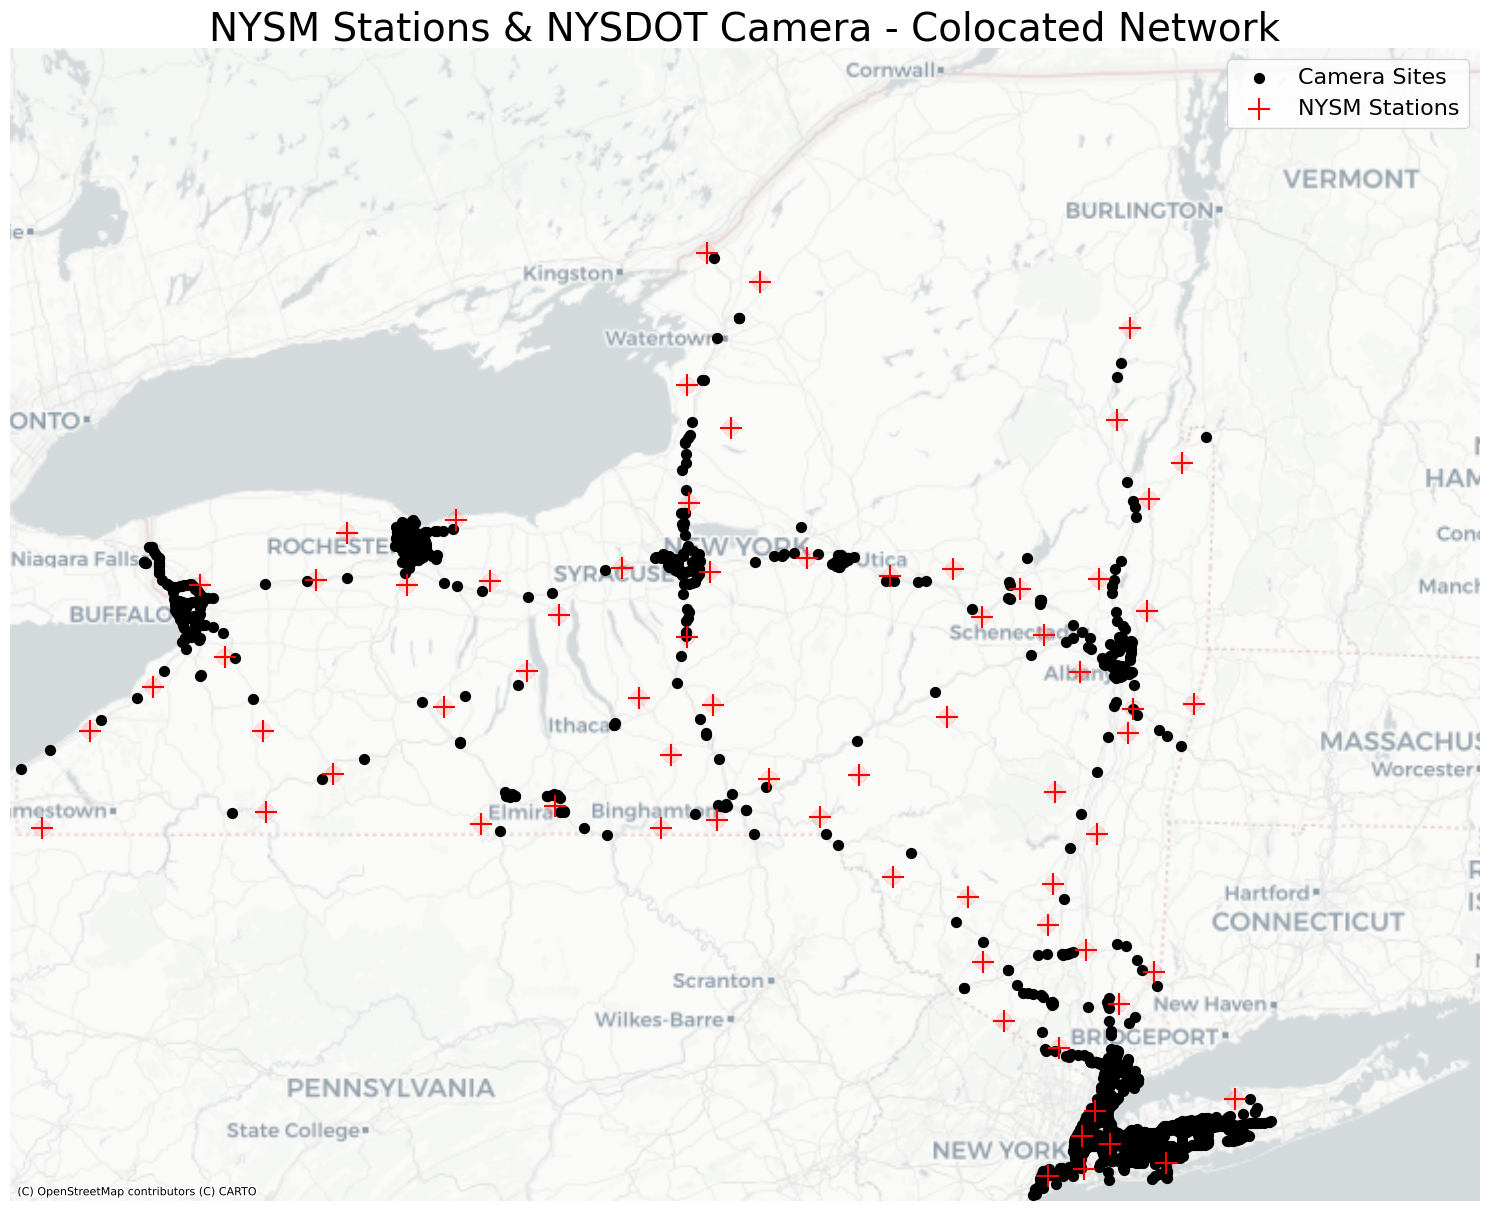

In [48]:
# To run:
plot_all_nysm_and_cameras(coords_mapped) # For plotting all stations and sites on same map


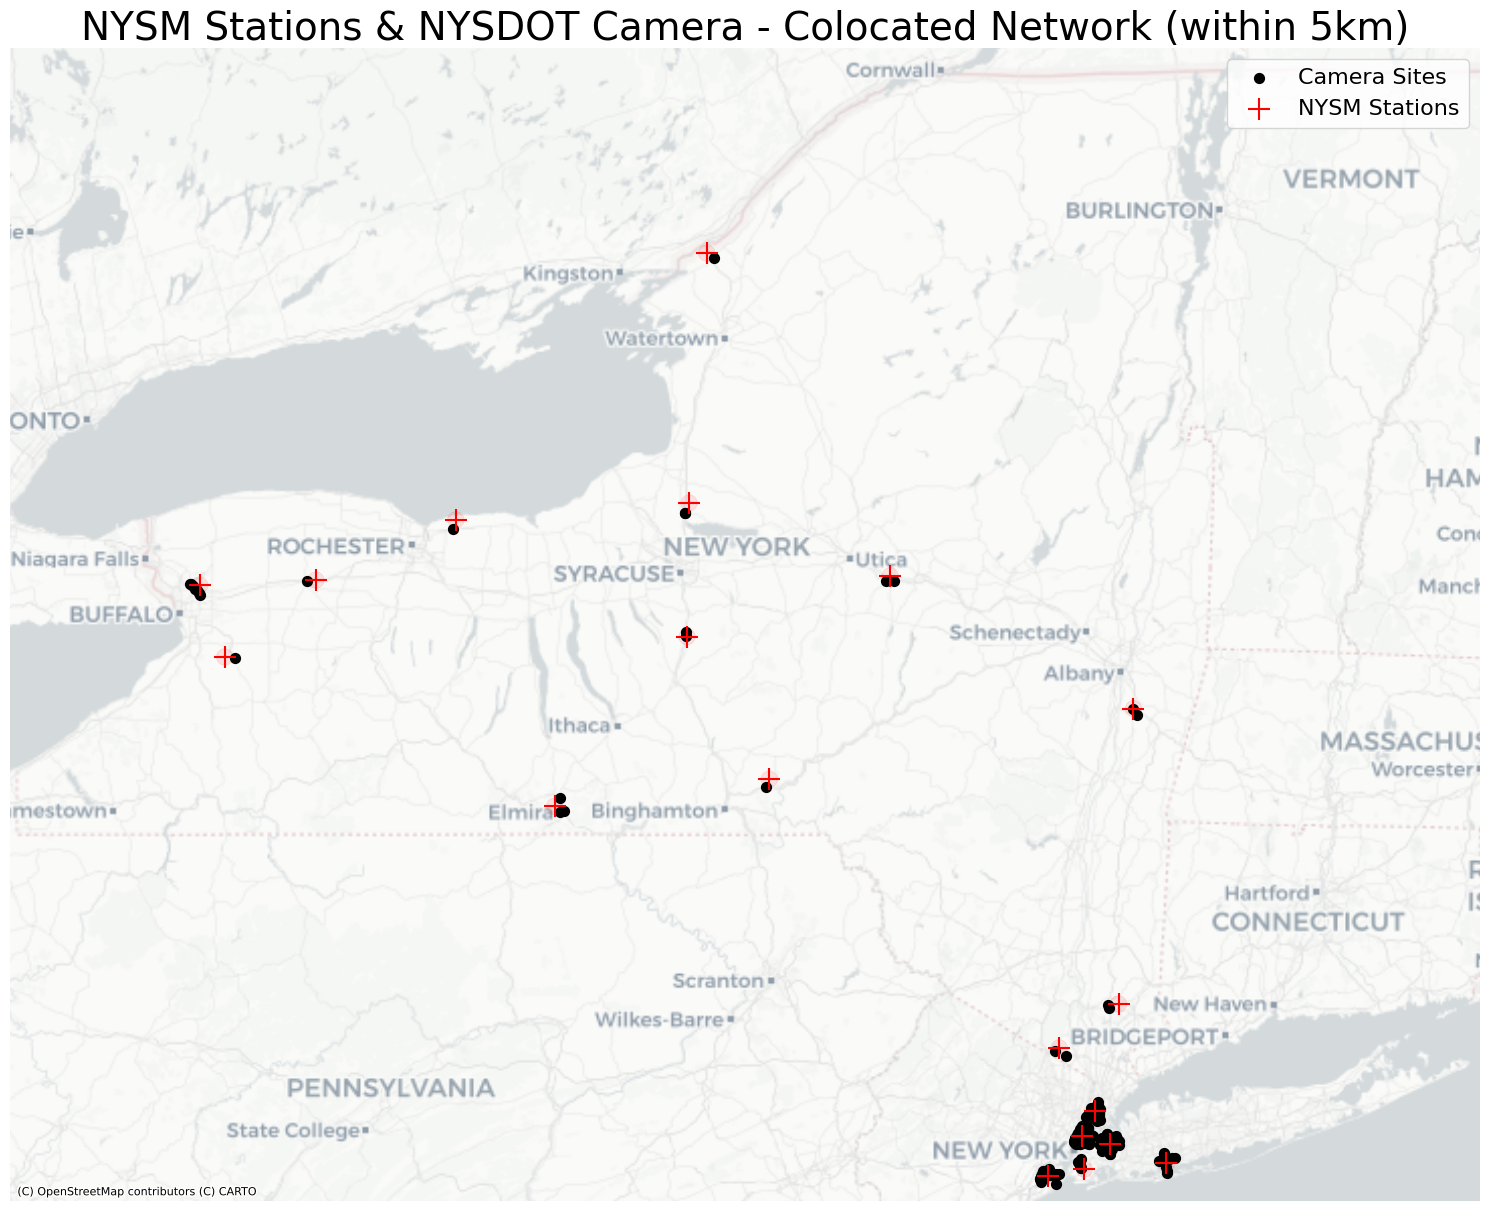

In [50]:
plot_all_nysm_and_cameras(coords_5km) # For plotting only those that are within 5-km

In [ ]:
# For each nysm station, collect the list of sites we should consider

# Subset to be within 2km
station_listcams = nysm_cam_mapping.groupby(["station"])['site_id'].agg(list).reset_index()

station_listcams

# Reference: Code to investigate nans

In [ ]:
# investigate nans (which we've filtered out in the above function)
# Looks like sometimes the snow depth gauge isn't working. Seemed to be the case for like all of October 2024 for BEAC

d_ex = xr.open_dataset('/home/csutter/NYSM/netcdf/proc/2024/10/20241014.nc')
beac = d_ex.sel(station = 'BEAC')
beac_first = beac.isel(time_5M=287)
beac_last = beac.isel(time_5M=-1)

beac_snow_first = beac_first['snow_depth'].item()
beac_snow_last = beac_last['snow_depth'].item()

print(beac_snow_first)
print(beac_snow_last)

# Reference: Code to investigate outliers
- Code is just for reference. We fixed the outliers by using 00:05 for the first reading of the day rather than 00:00 which contains the accumulation from the previous day, and it messed up the precip deltas

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import os

def investigate_case(timestamp_str, target_station, var_name='precip'):
    # 1. Parse the timestamp
    ts = pd.to_datetime(timestamp_str)
    year  = ts.strftime('%Y')
    month = ts.strftime('%m')
    date_str = ts.strftime('%Y%m%d') # Result: '20241014'
    
    # 2. Build the exact path based on your structure
    # Path: /home/csutter/NYSM/netcdf/proc/YYYY/MM/YYYYMMDD.nc
    file_path = f"/home/csutter/NYSM/netcdf/proc/{year}/{month}/{date_str}.nc"
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    # 3. Open and Plot
    ds = xr.open_dataset(file_path)
    
    try:
        station_data = ds[var_name].sel(station=target_station)
        
        plt.figure(figsize=(12, 5))
        station_data.plot(marker='.', linestyle='-', linewidth=0.5, color='crimson')
        
        # Mark the hour of the anomaly
        plt.axvline(ts, color='black', linestyle='--', label=f'Outlier Hour: {ts.strftime("%H:%M")}')
        
        plt.title(f"Detailed Analysis: {target_station} | {date_str} | {var_name}")
        plt.ylabel(f"Value ({ds[var_name].attrs.get('units', 'units')})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        # Print the values around that hour to see the "Jump"
        print(f"\n--- 5-Minute Values around {ts.strftime('%H:%M')} ---")
        window = station_data.sel(time_5M=slice(ts - pd.Timedelta(minutes=30), ts + pd.Timedelta(minutes=30)))
        print(window.to_series())

    finally:
        ds.close()

# Test with your specific case
investigate_case("2024-10-14 01:00", "ADDI", var_name='precip')

In [ ]:
import xarray as xr
import pandas as pd
import os

def investigate_raw_values(timestamp_str, target_station, var_name='precip'):
    ts = pd.to_datetime(timestamp_str)
    year, month, date_str = ts.strftime('%Y'), ts.strftime('%m'), ts.strftime('%Y%m%d')
    file_path = f"/home/csutter/NYSM/netcdf/proc/{year}/{month}/{date_str}.nc"
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    ds = xr.open_dataset(file_path)
    station_data = ds[var_name].sel(station=target_station)

    # 1. Print the absolute first value of the day (Midnight)
    first_val = station_data.isel(time_5M=0).values
    print(f"--- Midnight (00:00) Raw Value: {first_val} ---")

    # 2. Print the 5-minute raw values around your flagged hour
    print(f"\n--- Raw 5-Min {var_name} Values around {ts.strftime('%H:%M')} ---")
    
    # Looking from the top of the previous hour to the flagged hour
    start_look = ts - pd.Timedelta(hours=1)
    window = station_data.sel(time_5M=slice(start_look, ts))
    
    # Convert to series for a clean timestamped list
    print(window.to_series())

    ds.close()

# Investigation
investigate_raw_values("2024-10-14 01:00", "ADDI", var_name='precip')